In [ ]:
#-----------------------------------------------------
# IMORTING CSV FILES AND PERFORMING REQUIRED OPERTIONS
#-----------------------------------------------------

import os
import pandas as pd
import numpy as np
def load_sequence_data(root_dir, seq_length=96):
    X, y = [], []
    label_map = {} 
    new_label = 0 
    for label, folder in enumerate(sorted(os.listdir(root_dir))): 
        folder_path = os.path.join(root_dir, folder)
        if os.path.isdir(folder_path):
            csv_files = [f for f in sorted(os.listdir(folder_path)) if f.endswith(".csv")]
            if len(csv_files) <= 1:
                print(f"Skipping folder {folder}: Only {len(csv_files)} CSV file(s) found.")
                continue  
            print(f"Processing folder: {folder}")
            label_map[label] = new_label 
            new_label += 1 
            for csv_file in csv_files:
                csv_path = os.path.join(folder_path, csv_file)
                try:
                    df = pd.read_csv(csv_path)
                    if "TIME" in df.columns:
                        df = df[df["TIME"] >= 20]  
                        df.drop(columns=["TIME"], inplace=True) 
                    if df.shape[1] > 96:
                        print(f"Fixing {csv_file}: Found {df.shape[1]} features, trimming extra columns...")
                        df = df.iloc[:, :96] 
                    elif df.shape[1] < 96:
                        print(f"Skipping {csv_file}: Expected 96 features, found {df.shape[1]}")
                        continue 
                    if len(df) >= seq_length:
                        seq = df.iloc[:seq_length].values 
                        print(seq.shape)                        
                        if seq.shape == (seq_length, 96): 
                            X.append(seq)
                            y.append(label_map[label]) 
                        else:
                            print(f"Skipping sequence in {csv_file}: Shape mismatch {seq.shape}")
                except Exception as e:
                    print(f"Error processing {csv_file}: {e}")
    if X: 
        X = np.array(X, dtype=np.float32)
    else:
        print("No valid sequences found!")
        return None, None
    y = np.array(y, dtype=np.int64) 
    print(f"Final Data Shape: {X.shape}, Labels Shape: {y.shape}")
    print(f"Unique Labels After Mapping: {np.unique(y)}")
    return X, y
X, y = load_sequence_data("Operation_csv_data")
if X is not None:
    print(f"Data shape: {X.shape}, Labels shape: {y.shape}")
else:
    print("Error: No valid data loaded.") 

In [9]:
#----------------------------------------------------------------------
# SPILITTING THE DATA INTO 80% TRAINING, 10% TESTING AND 10% VALIDATION
#----------------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Labels shape: {y_val.shape}")
print(f"Testing data shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training data shape: (954, 96, 96), Labels shape: (954,)
Validation data shape: (119, 96, 96), Labels shape: (119,)
Testing data shape: (120, 96, 96), Labels shape: (120,)


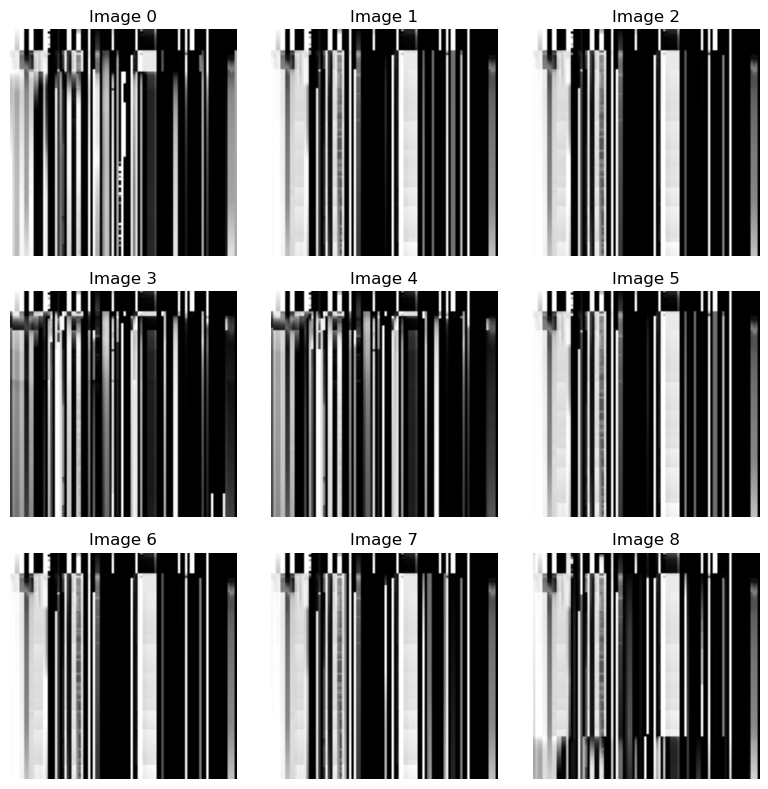

In [15]:
#---------------------------------------
# VISUALIZING SOME OF THE TRAININIG DATA
#---------------------------------------

import matplotlib.pyplot as plt
num_images = 9

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    if i < X_train_scaled.shape[0]:
        ax.imshow(X_train_scaled[i], cmap='gray')
        ax.set_title(f"Image {i}")
        ax.axis('off') 
    else:
        ax.axis('off') 
plt.tight_layout()
plt.show()

In [13]:
#--------------
# NORMALIZATION
#--------------

from sklearn.preprocessing import MinMaxScaler

n_train, h, w = X_train.shape
n_val = X_val.shape[0]
n_test = X_test.shape[0]

X_train_flat = X_train.reshape(n_train, -1)
X_val_flat = X_val.reshape(n_val, -1)
X_test_flat = X_test.reshape(n_test, -1)

scaler = MinMaxScaler()
X_train_scaled_flat = scaler.fit_transform(X_train_flat)

X_val_scaled_flat = scaler.transform(X_val_flat)
X_test_scaled_flat = scaler.transform(X_test_flat)

X_train_scaled = X_train_scaled_flat.reshape(n_train, h, w)
X_val_scaled = X_val_scaled_flat.reshape(n_val, h, w)
X_test_scaled = X_test_scaled_flat.reshape(n_test, h, w)

print(f"Scaled Training data shape: {X_train_scaled.shape}")
print(f"Scaled Validation data shape: {X_val_scaled.shape}")
print(f"Scaled Testing data shape: {X_test_scaled.shape}")


Scaled Training data shape: (954, 96, 96)
Scaled Validation data shape: (119, 96, 96)
Scaled Testing data shape: (120, 96, 96)


In [3]:
#----------------------------------
# IMPORTING LIBRARIES AND FUNCTIONS
#----------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization, Input, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix

In [19]:
# ------------------------------------
# MODEL: 01, ONE-LAYER FULLY CONNECTED
# ------------------------------------

input_shape = (96, 96)
num_classes = 12
optimizer = Adam(learning_rate=0.001)
model1 = Sequential([
    Input(shape=(96, 96)), 
    Flatten(),     
    Dense(num_classes, activation='softmax') 
])
model1.compile(optimizer=optimizer,
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 12)                  │         110,604 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 110,604 (432.05 KB)

 Trainable params: 110,604 (432.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#-------------------
# TRAINING: MODEL_01
#-------------------

history1 = model1.fit(X_train_scaled, y_train,
                      epochs=250,
                      validation_data=(X_val_scaled, y_val),
                      verbose=1)

In [87]:
#-----------------
# TESTING ACCURACY
#-----------------

test_loss1, test_acc1 = model1.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Model 1 Test Accuracy:: {test_acc1*100:.2f}%")

4/4 - 0s - 6ms/step - accuracy: 0.9250 - loss: 0.1414
Model 1 Test Accuracy:: 92.50%


In [89]:
#-----------------------
# PREDICTION ON TEST SET
#-----------------------

y_pred1 = np.argmax(model1.predict(X_test_scaled), axis=1)
cm1 = confusion_matrix(y_test, y_pred1, normalize='true')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


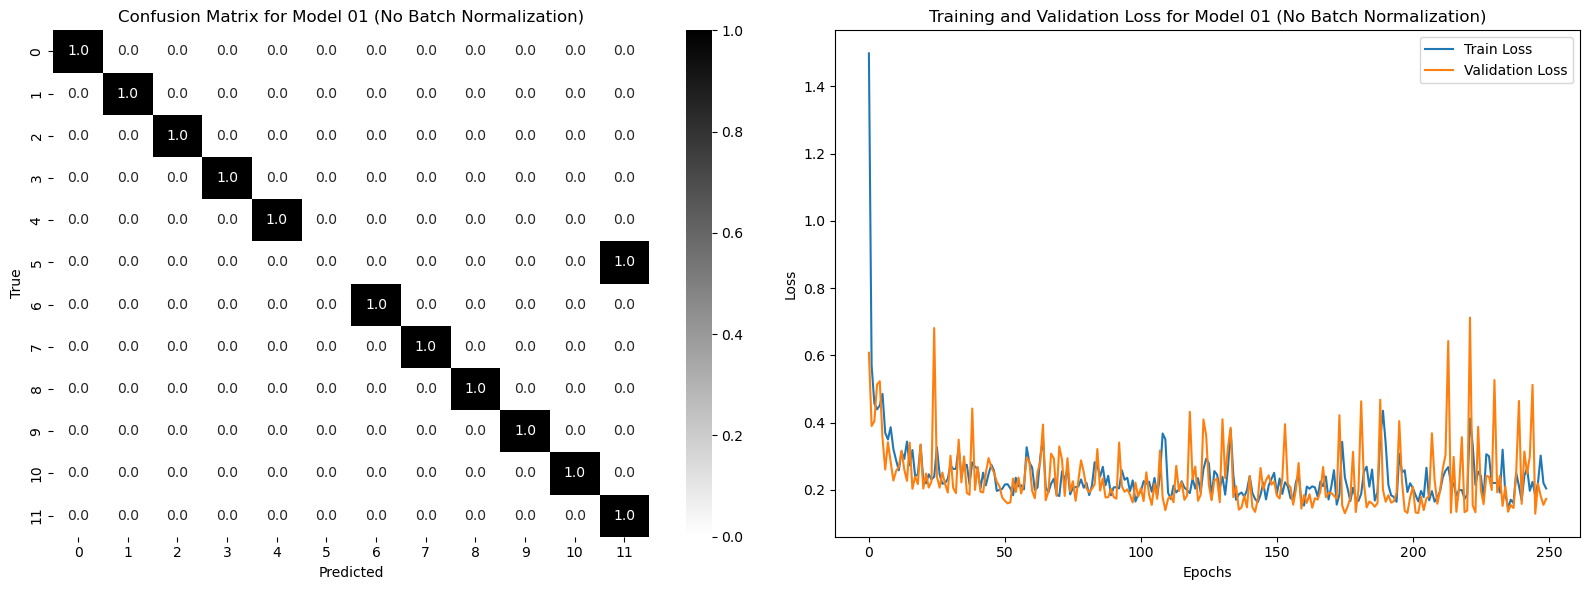

In [91]:
#----------------------------------------------
# CONFUSION MATRIX AND LOSS CURVES FOR MODEL_01
#----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm1, annot=True, fmt='.1f', cmap='binary', ax=axes[0])
axes[0].set_title('Confusion Matrix for Model 01 (No Batch Normalization)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

axes[1].plot(history1.history['loss'], label='Train Loss')
axes[1].plot(history1.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss for Model 01 (No Batch Normalization)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#################################################################################################################################################
-------------------------------------------------------------------------------------------------------------------------------------------------

In [73]:
#--------------------------------------------------------------
# MODEL: 02, ONE-LAYER FULLY CONNECTED WITH BATCH NORMALIZATION
#--------------------------------------------------------------

from tensorflow.keras.regularizers import l2
model2 = Sequential([
    Input(shape=input_shape),
    Flatten(),
    BatchNormalization(),                
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model2.compile(optimizer=optimizer,
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 9216)                │          36,864 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,218,700 (4.65 MB)

 Trainable params: 1,200,012 (4.58 MB)

 Non-trainable params: 18,688 (73.00 KB)

In [ ]:
#-------------------
# TRAINING: MODEL_02
#-------------------

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
early_stop_1= EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
history2 = model2.fit(
    X_train_scaled, y_train,
    epochs=250,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop_1,reduce_lr],
    verbose=1
)

In [77]:
#-----------------
# TESTING ACCURACY
#-----------------

test_loss2, test_acc2 = model2.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Model 1 Test Accuracy:: {test_acc2*100:.2f}%")

4/4 - 0s - 13ms/step - accuracy: 0.8917 - loss: 0.2312
Model 1 Test Accuracy:: 89.17%


In [79]:
#-----------------
# PREDICTION
#-----------------

y_pred2 = np.argmax(model2.predict(X_test_scaled), axis=1)
cm2 = confusion_matrix(y_test, y_pred2, normalize='true')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


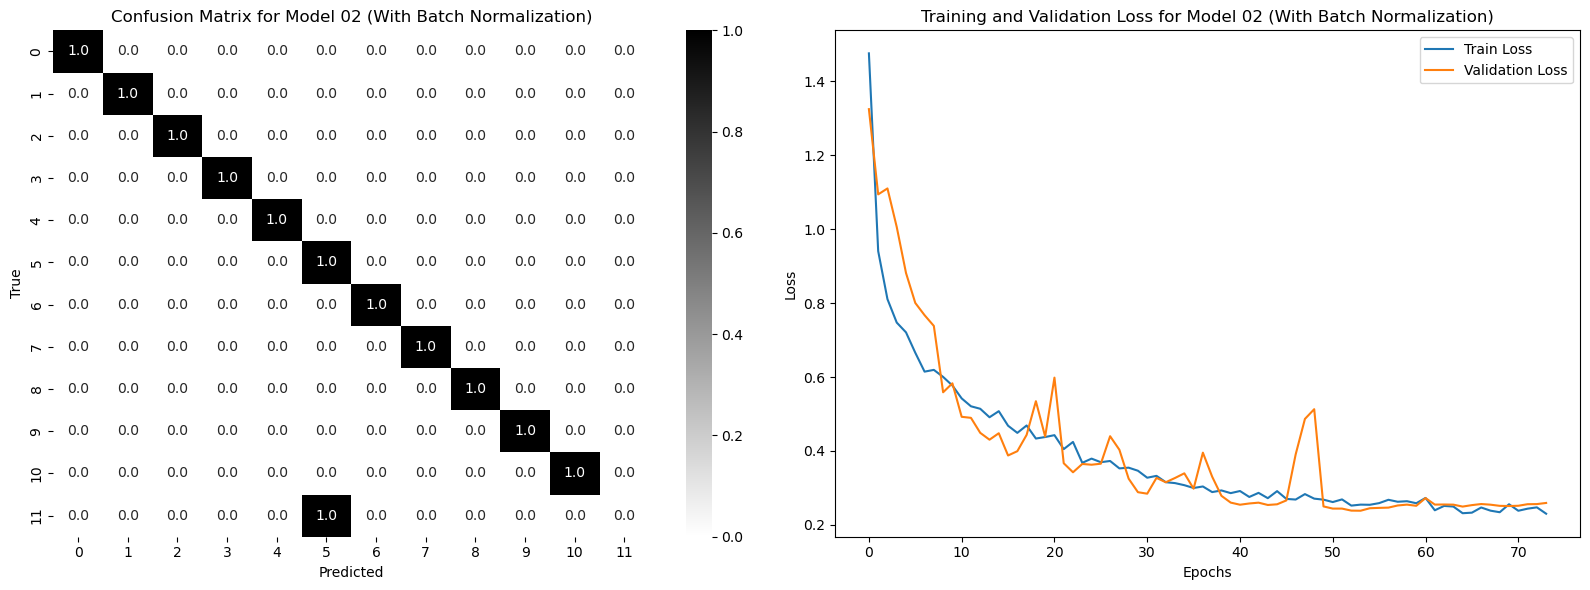

In [81]:
#----------------------------------------------
# CONFUSION MATRIX AND LOSS CURVES FOR MODEL_02
#----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm2, annot=True, fmt='.1f', cmap='binary', ax=axes[0])
axes[0].set_title('Confusion Matrix for Model 02 (With Batch Normalization)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

axes[1].plot(history2.history['loss'], label='Train Loss')
axes[1].plot(history2.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss for Model 02 (With Batch Normalization)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#################################################################################################################################################
-------------------------------------------------------------------------------------------------------------------------------------------------

In [153]:
# -----------------------------------------------------------------------
# MODEL: 03, FOUR-LAYER FULLY CONNECTED LAYER WITH NO BATCH NORMALIZATION
# -----------------------------------------------------------------------

model3 = Sequential([
    Input(shape=input_shape),            
    Flatten(),                           
    Dense(128, activation='relu'),      
    Dense(64, activation='relu'),       
    Dense(32, activation='relu'),      
    Dense(num_classes, activation='softmax') 
])
model3.compile(optimizer=Adam(learning_rate=0.0001),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)                 │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 12)                  │             396 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,190,508 (4.54 MB)

 Trainable params: 1,190,508 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#-------------------
# TRAINING: MODEL_03
#-------------------

history3 = model3.fit(X_train_scaled, y_train,
                      epochs=250,
                      validation_data=(X_val_scaled, y_val),
                      verbose=1)

In [157]:
#-----------------
# TESTING ACCURACY
#-----------------

test_loss3, test_acc3 = model3.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Model 1 Test Accuracy:: {test_acc3*100:.2f}%")

4/4 - 0s - 10ms/step - accuracy: 0.8917 - loss: 0.1456
Model 1 Test Accuracy:: 89.17%


In [159]:
#-----------------
# PREDICTION
#-----------------

y_pred3 = np.argmax(model3.predict(X_test_scaled), axis=1)
cm3 = confusion_matrix(y_test, y_pred3, normalize='true')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


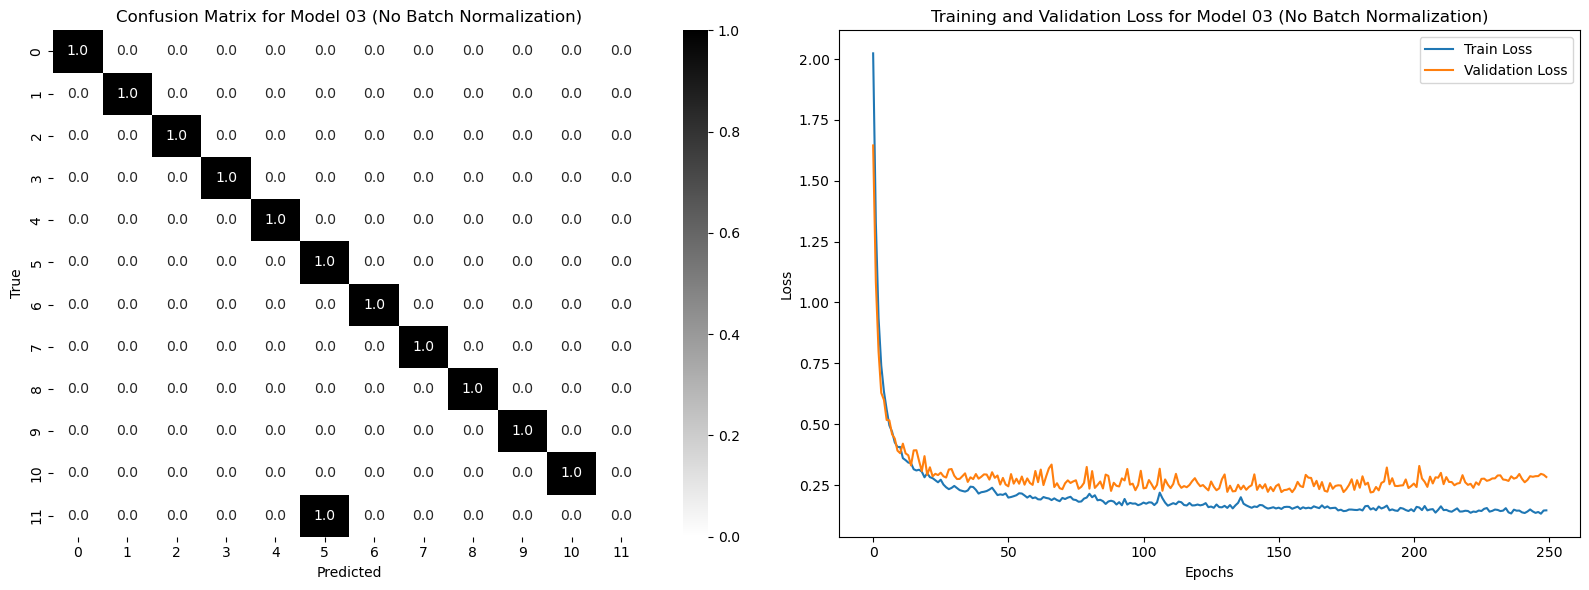

In [161]:
#----------------------------------------------
# CONFUSION MATRIX AND LOSS CURVES FOR MODEL_03
#----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm3, annot=True, fmt='.1f', cmap='binary', ax=axes[0])
axes[0].set_title('Confusion Matrix for Model 03 (No Batch Normalization)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

axes[1].plot(history3.history['loss'], label='Train Loss')
axes[1].plot(history3.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss for Model 03 (No Batch Normalization)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
#################################################################################################################################################
-------------------------------------------------------------------------------------------------------------------------------------------------

In [103]:
# --------------------------------------------------------------------
# MODEL: 04, FOUR-LAYER FULLY CONNECTED LAYER WITH BATCH NORMALIZATION
# --------------------------------------------------------------------

model4 = Sequential([
    Input(shape=input_shape),
    Flatten(),
    BatchNormalization(),
    Dense(256, activation='relu', kernel_regularizer='l2'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(128, activation='relu', kernel_regularizer='l2'), 
    Dropout(0.3),
    BatchNormalization(),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

optimizer = optimizer = Adam(learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=100, decay_rate=0.9))
model4.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model4.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)                 │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 9216)                │          36,864 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 256)                 │       2,359,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 12)                  │             780 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,439,884 (9.31 MB)

 Trainable params: 2,420,684 (9.23 MB)

 Non-trainable params: 19,200 (75.00 KB)

In [ ]:
#-------------------
# TRAINING: MODEL_04
#-------------------

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history4 = model4.fit(X_train_scaled, y_train,
                      epochs=250, batch_size=32,
                      validation_data=(X_val_scaled, y_val), callbacks=[early_stop],
                      verbose=1)

In [107]:
#-----------------
# TESTING ACCURACY
#-----------------

test_loss4, test_acc4 = model4.evaluate(X_test_scaled, y_test, verbose=2)
print(f"Model 1 Test Accuracy:: {test_acc4*100:.2f}%")

4/4 - 0s - 15ms/step - accuracy: 0.8750 - loss: 0.4183
Model 1 Test Accuracy:: 87.50%


In [109]:
#-----------
# PREDICTION
#-----------

y_pred4 = np.argmax(model4.predict(X_test_scaled), axis=1)
cm4 = confusion_matrix(y_test, y_pred4, normalize='true')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


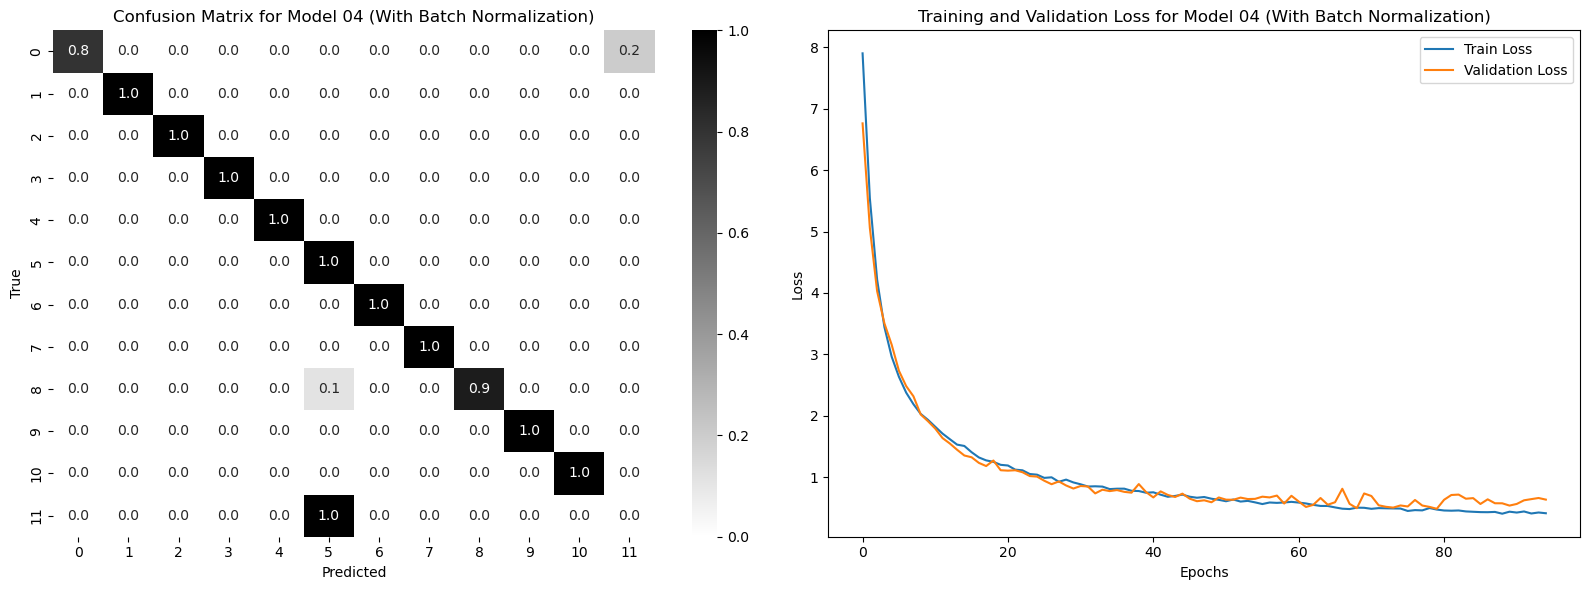

In [111]:
#----------------------------------------------
# CONFUSION MATRIX AND LOSS CURVES FOR MODEL_04
#----------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm4, annot=True, fmt='.1f', cmap='binary', ax=axes[0])
axes[0].set_title('Confusion Matrix for Model 04 (With Batch Normalization)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

axes[1].plot(history4.history['loss'], label='Train Loss')
axes[1].plot(history4.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training and Validation Loss for Model 04 (With Batch Normalization)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

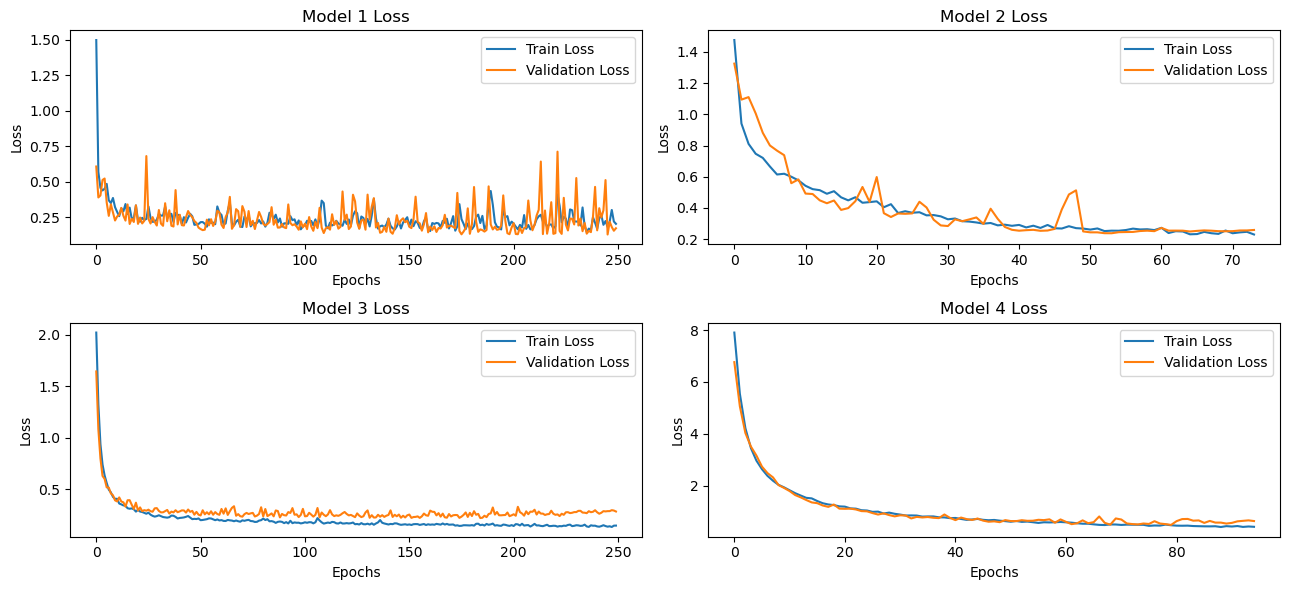

In [163]:
#--------------------
# Model 01 Loss Curves
#--------------------

fig, axs = plt.subplots(2, 2, figsize=(13, 6))
axs[0, 0].plot(history1.history['loss'], label='Train Loss')
axs[0, 0].plot(history1.history['val_loss'], label='Validation Loss')
axs[0, 0].set_title('Model 1 Loss')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()


#--------------------
# Model 02 Loss Curves
#--------------------
axs[0, 1].plot(history2.history['loss'], label='Train Loss')
axs[0, 1].plot(history2.history['val_loss'], label='Validation Loss')
axs[0, 1].set_title('Model 2 Loss')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

#--------------------
# Model 03 Loss Curves
#--------------------
axs[1, 0].plot(history3.history['loss'], label='Train Loss')
axs[1, 0].plot(history3.history['val_loss'], label='Validation Loss')
axs[1, 0].set_title('Model 3 Loss')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()

#--------------------
# Model 04 Loss Curves
#--------------------
axs[1, 1].plot(history4.history['loss'], label='Train Loss')
axs[1, 1].plot(history4.history['val_loss'], label='Validation Loss')
axs[1, 1].set_title('Model 4 Loss')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].legend()

plt.tight_layout()
plt.show()
